<a href="https://colab.research.google.com/github/majidali321/Random-Forest-Regressor/blob/main/California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from pandas.plotting import scatter_matrix
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import pandas as pd


In [35]:
data = fetch_california_housing()


In [36]:
data = fetch_california_housing(as_frame=True)
data = data.frame
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


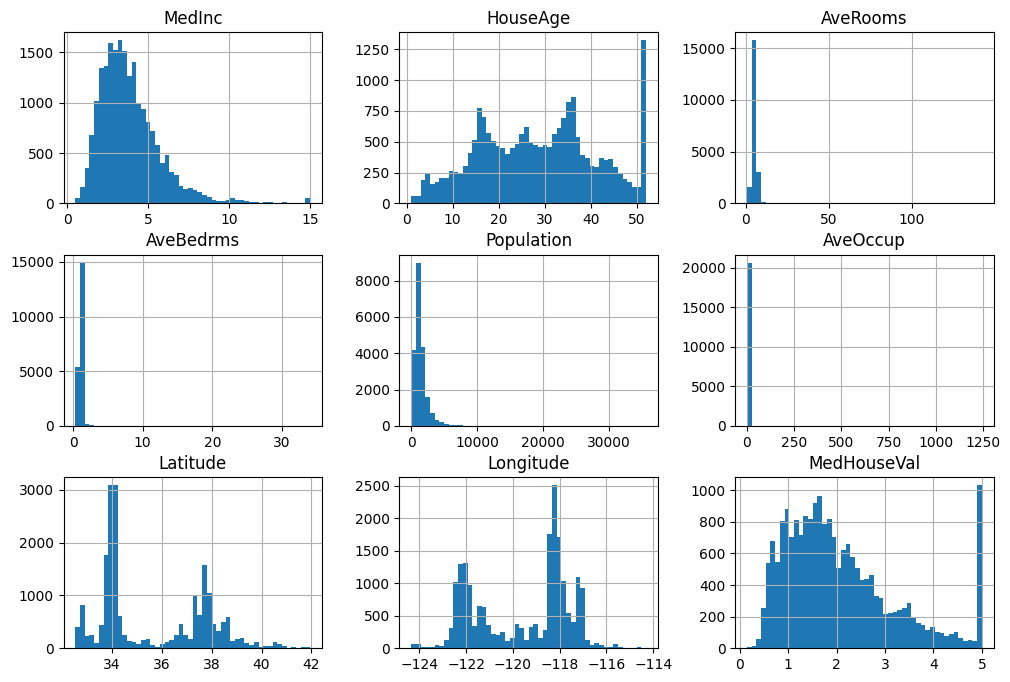

In [37]:
import matplotlib.pyplot as plt
data.hist(bins=50, figsize=(12,8))
plt.show()

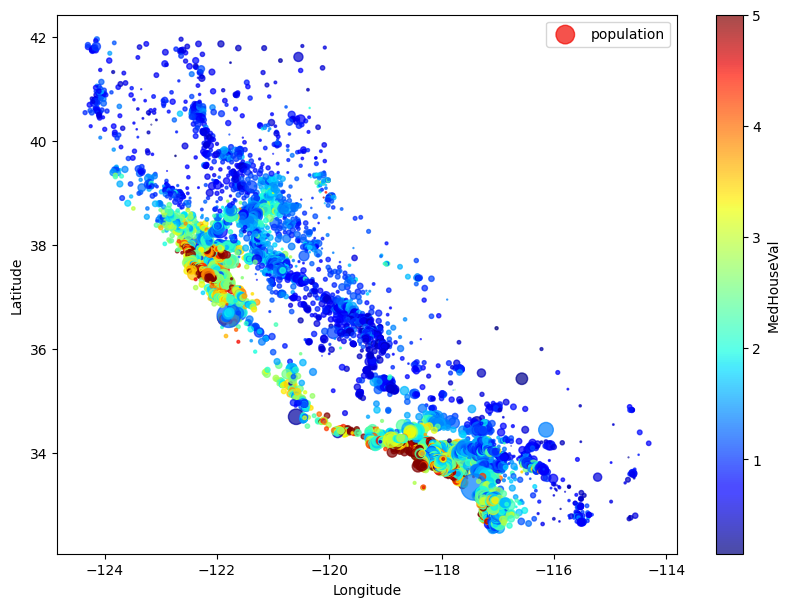

In [38]:
data.plot(kind="scatter", x="Longitude",y="Latitude", c="MedHouseVal", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7), s=data['Population']/100, label="population", alpha=0.7)
plt.show()

colorful bubbles are mentioned that high latitude and longitude houses are very expensive because they are near the ocean

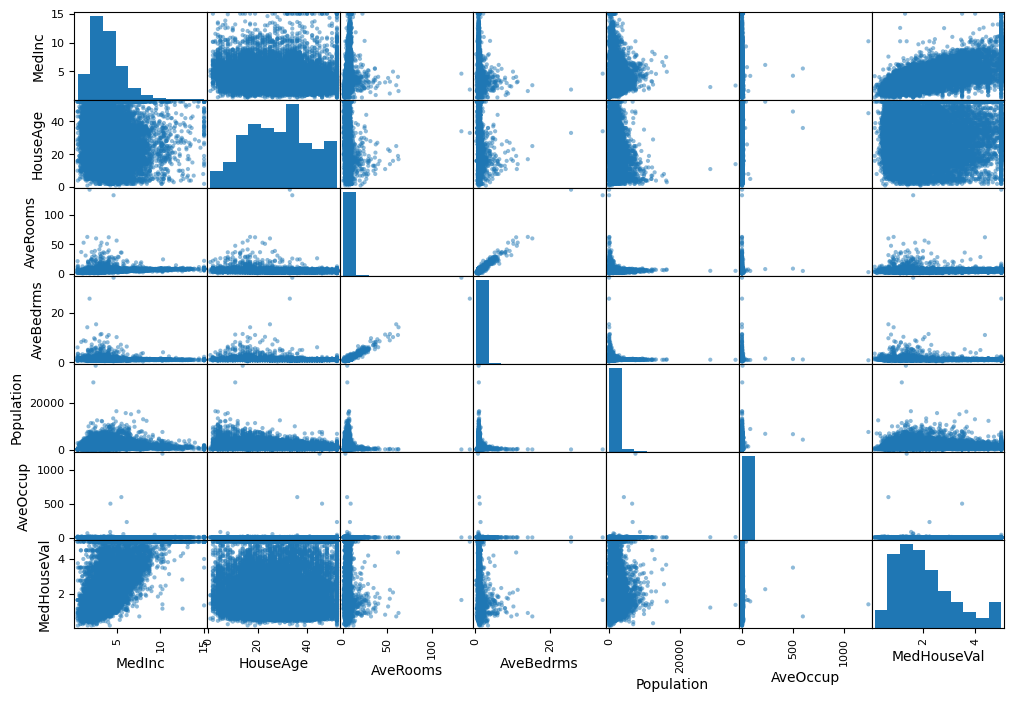

In [39]:

attributes = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','MedHouseVal']
scatter_matrix(data[attributes], figsize=(12,8))
plt.show()

If we check the correlation against MedHouseVal, we can see that all the other features show somewhat weak correlation, except for MedInc (Median Income). Let’s explore further

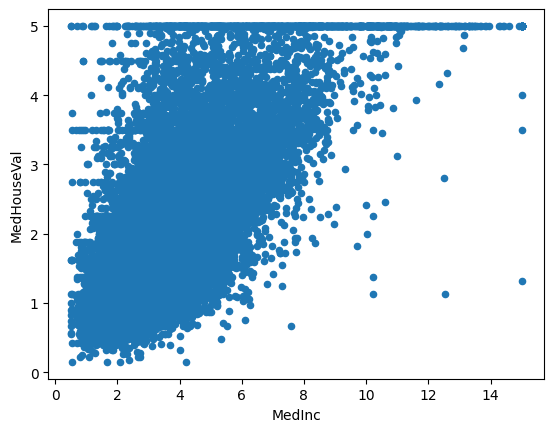

In [40]:
data.plot(kind="scatter", x="MedInc",y="MedHouseVal")
plt.show()

The above plot shows a strong linear correlation between Median Income and House Value. Also we can see some instances in the data are capped and they form lines. This can create problem, they should be preprocessed.

### Below code display the numerical value of correlation of features against “MedHouseVal”

In [41]:
corr = data.corr()
corr['MedHouseVal'].sort_values(ascending=True)

,MedHouseVal
Latitude,-0.144160
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737
HouseAge,0.105623
AveRooms,0.151948
MedInc,0.688075
MedHouseVal,1.000000


As expected MedInc(Median Income) show a strong correlation.

### **Validate Data**

In [42]:
data.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [43]:
data.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [44]:
X =data.drop('MedHouseVal', axis=1)
y =data.MedHouseVal
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [46]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [47]:
regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

regression_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(random_state=42))])

### **For better accuracy**, standard scaling is applied. The Pipeline first applies the standardScaler() function to the features and then calls the Random Forest Regressor Model. Using a Pipeline makes the code cleaner, reusable, and reduces a lot of boilerplate code.

In [48]:
y_pred = regression_pipeline.predict(X_test)
r2_score( y_test, y_pred)

0.8052747336256919

# "Achieved 80% accuracy using Random Forest Regressor!